In [ ]:
import os
import random
import time
import json
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, datasets, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, f1_score
import numpy as np

import json
import datetime

from google.colab import files
import zipfile
import os

In [ ]:
# Upload file ZIP
uploaded = files.upload()

import zipfile

zip_path = "PBL #3 - Image Scene Classification Case.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

Saving PBL #3 - Image Scene Classification Case.zip to PBL #3 - Image Scene Classification Case.zip


In [ ]:
import os
print(os.listdir(train_dir))


SyntaxError: invalid syntax (ipython-input-3852972301.py, line 2)

In [ ]:
# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Konfigurasi ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_dir = "traing_data"   # sesuai nama folder kamu
test_dir = "test_data"


In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# train_datagen = ImageDataGenerator(rescale=1/255., validation_split=0.2)

# train_gen = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     subset="training"
# )

# val_gen = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     subset="validation"
# )

# test_datagen = ImageDataGenerator(rescale=1/255.)
# test_gen = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     shuffle=False
# )

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True)
]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 197s 518ms/step - accuracy: 0.5602 - loss: 1.0814 - val_accuracy: 0.5959 - val_loss: 1.1228
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 167s 475ms/step - accuracy: 0.6738 - loss: 0.8277 - val_accuracy: 0.5874 - val_loss: 1.0350
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 166s 473ms/step - accuracy: 0.6951 - loss: 0.7753 - val_accuracy: 0.6394 - val_loss: 0.9304
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 165s 470ms/step - accuracy: 0.7112 - loss: 0.7460 - val_accuracy: 0.5681 - val_loss: 1.1349
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 165s 470ms/step - accuracy: 0.7295 - loss: 0.7130 - val_accuracy: 0.5649 - val_loss: 1.2449
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 167s 477ms/step - accuracy: 0.7358 - loss: 0.6886 - val_accuracy: 0.5638 - val_loss: 1.4156
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 165s 470ms/step - accuracy: 0.7426 - loss: 0.6687 - val_accuracy: 0.5613 - val_loss: 1.1572
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 164s 468ms/step - accuracy: 0.7502 -

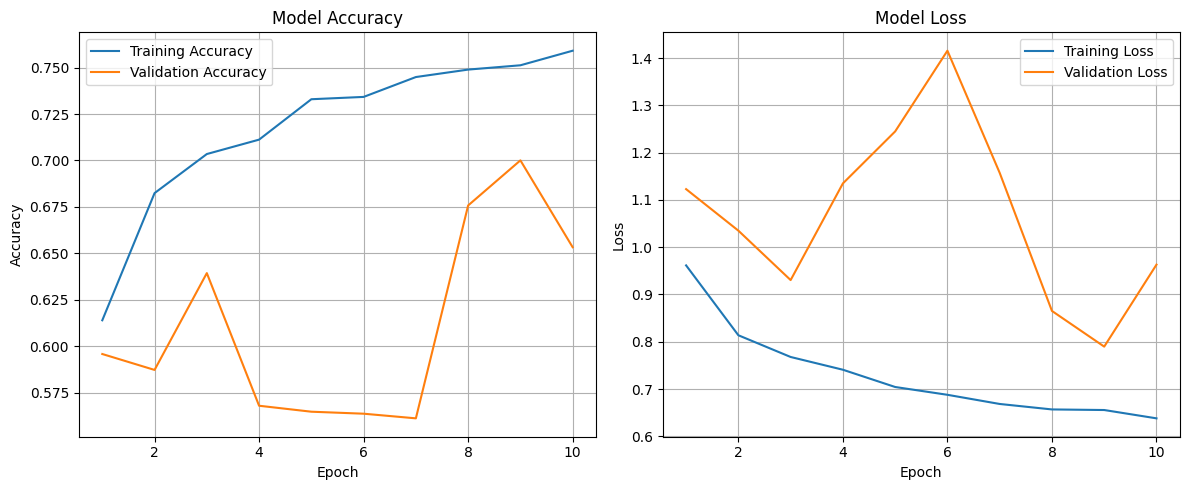

In [ ]:
# --- Ambil nilai dari history ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


----------
ResNet Moodified

In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet101(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-40]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True)
]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 276s 668ms/step - accuracy: 0.4995 - loss: 1.2179 - val_accuracy: 0.5004 - val_loss: 1.2231
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 599ms/step - accuracy: 0.6106 - loss: 0.9854 - val_accuracy: 0.4611 - val_loss: 1.5848
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 221s 628ms/step - accuracy: 0.6535 - loss: 0.9035 - val_accuracy: 0.5399 - val_loss: 1.2171
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 209s 594ms/step - accuracy: 0.6624 - loss: 0.8793 - val_accuracy: 0.3313 - val_loss: 2.7397
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 221s 629ms/step - accuracy: 0.6785 - loss: 0.8413 - val_accuracy: 0.5428 - val_loss: 1.1677
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 225s 641ms/step - accuracy: 0.6981 - loss: 0.7970 - val_accuracy: 0.5481 - val_loss: 1.1643
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 236s 672ms/step - accuracy: 0.7021 - loss: 0.7738 - val_accuracy: 0.6098 - val_loss: 1.0418
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 207s 590ms/step - accuracy: 0.7087 -

----------------------------


In [ ]:
# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Konfigurasi ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_dir = "traing_data"   # sesuai nama folder kamu
test_dir = "test_data"


In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)   # tambahan dropout untuk cegah overfitting

# x = GlobalAveragePooling2D()(base_model.output)
# x = Dense(256, activation="relu")(x)
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
from tensorflow.keras.callbacks import ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

# callbacks = [
#     EarlyStopping(patience=5, restore_best_weights=True),
#     ModelCheckpoint("best_resnet.keras", save_best_only=True)
# ]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 240s 622ms/step - accuracy: 0.4724 - loss: 1.2883 - val_accuracy: 0.5553 - val_loss: 1.1402 - learning_rate: 1.0000e-04
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 196s 557ms/step - accuracy: 0.6111 - loss: 0.9972 - val_accuracy: 0.5481 - val_loss: 1.0977 - learning_rate: 1.0000e-04
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 192s 547ms/step - accuracy: 0.6526 - loss: 0.9183 - val_accuracy: 0.4026 - val_loss: 1.6697 - learning_rate: 1.0000e-04
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 554ms/step - accuracy: 0.6684 - loss: 0.8860 - val_accuracy: 0.6066 - val_loss: 1.0125 - learning_rate: 1.0000e-04
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 552ms/step - accuracy: 0.6824 - loss: 0.8509 - val_accuracy: 0.5738 - val_loss: 1.0949 - learning_rate: 1.0000e-04
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 554ms/step - accuracy: 0.6896 - loss: 0.8173 - val_accuracy: 0.6031 - val_loss: 1.0110 - learning_rate: 1.0000e-04
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 

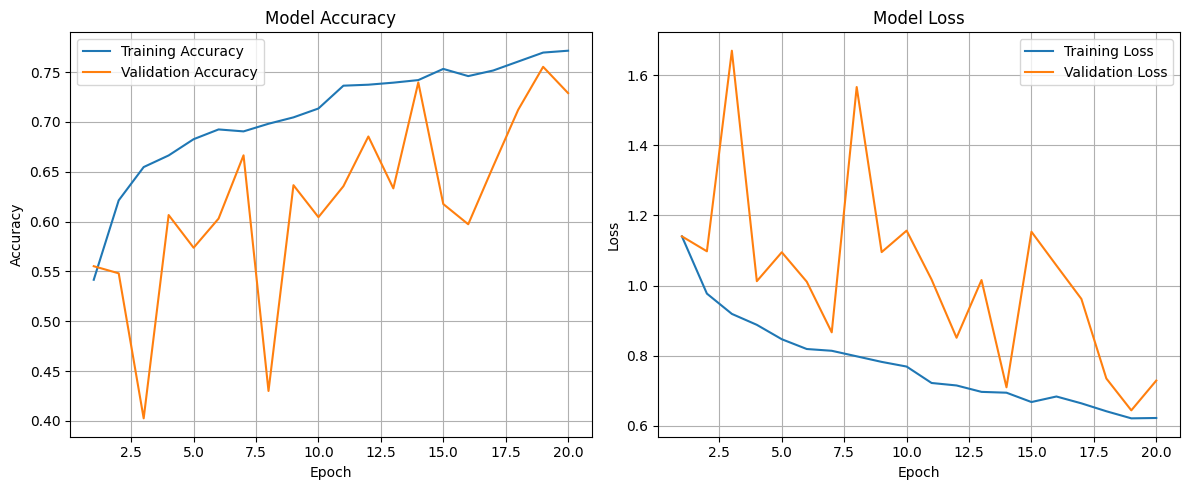

In [ ]:
# --- Ambil nilai dari history ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


------------------------


In [ ]:
# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Konfigurasi ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_dir = "traing_data"   # sesuai nama folder kamu
test_dir = "test_data"


In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-40]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)   # tambahan dropout untuk cegah overfitting
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
from tensorflow.keras.callbacks import ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

# callbacks = [
#     EarlyStopping(patience=5, restore_best_weights=True),
#     ModelCheckpoint("best_resnet.keras", save_best_only=True)
# ]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

NameError: name 'ResNet50' is not defined